# Bab 2: Data and Sampling Distributions

Notebook ini merangkum Bab 2 buku *Practical Statistics for Data Scientists* (Bruce, Bruce & Gedeck). Bab ini membahas kenapa sampling masih penting di era big data, bagaimana perilaku sebuah statistik (misalnya mean) berubah-ubah dari sampel ke sampel, serta sejumlah distribusi probabilitas yang sering muncul dalam praktik data science.

Dataset yang dipakai sama dengan buku, diambil dari repo resminya di `https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/`:

- `loans_income.csv` — pendapatan tahunan 50.000 peminjam, dipakai untuk demonstrasi sampling distribution, bootstrap, dan confidence interval
- `sp500_data.csv.gz` — return harian saham, kolom `NFLX` (Netflix) dipakai untuk contoh long-tailed distribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
pd.set_option("display.precision", 3)
rng = np.random.default_rng(42)

BASE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"
loans_income = pd.read_csv(BASE + "loans_income.csv").squeeze("columns")
loans_income.head()

,x
0,67000
1,52000
2,100000
3,78762
4,37041


## 1. Random Sampling dan Sample Bias

**Sampel** adalah subset data dari kumpulan yang lebih besar, disebut **populasi**. **Random sampling** berarti setiap anggota populasi punya peluang yang sama untuk terpilih ke dalam sampel.

Kenapa ini masih relevan walau data makin besar? Karena tujuan sampling bukan cuma menghemat biaya pengumpulan data, tapi memastikan sampel yang dipakai benar-benar mewakili populasi. Kalau cara pengambilan sampelnya bias (**sample bias**), sebesar apa pun datanya, kesimpulan yang diambil tetap bisa menyesatkan. Contoh klasik: survei lewat telepon rumah di masa lalu cenderung under-represent orang muda, karena mereka lebih jarang punya telepon rumah.

Konsep penting lain di sini adalah perbedaan antara **populasi** (kumpulan data lengkap atau teoretis yang jadi minat kita) dan **sampel** (bagian yang benar-benar kita amati/gunakan).

In [2]:
sampel_acak = loans_income.sample(n=1000, random_state=42)

print(f"Jumlah populasi (data lengkap): {len(loans_income):,}")
print(f"Jumlah sampel                 : {len(sampel_acak):,}")
print(f"Mean populasi                 : {loans_income.mean():,.0f}")
print(f"Mean sampel                   : {sampel_acak.mean():,.0f}")

Jumlah populasi (data lengkap): 50,000
Jumlah sampel                 : 1,000
Mean populasi                 : 68,761
Mean sampel                   : 66,536


## 2. Selection Bias

**Selection bias** terjadi ketika cara memilih data (secara sadar atau tidak) membuat sampel tidak lagi mewakili populasi yang ingin dipelajari. Ini beda dengan random sampling yang jelek karena faktor teknis, selection bias sering datang dari cara pertanyaan penelitian dirumuskan atau dari mencari pola *setelah* melihat data (data snooping).

Beberapa bentuk yang sering muncul:

- **Data snooping**: mengulik data dari berbagai sudut sampai ketemu sesuatu yang "menarik", padahal pola itu cuma kebetulan.
- **Vast search effect**: kalau cukup banyak kemungkinan dicoba, sesuatu yang terlihat signifikan pasti akan muncul, walau sebenarnya itu random.
- **Regression to the mean**: pengukuran ekstrem cenderung diikuti pengukuran yang lebih mendekati rata-rata pada kesempatan berikutnya, ini murni efek statistik, bukan perubahan nyata.

Bagian ini lebih konseptual daripada teknis, tapi penting untuk selalu ditanyakan sebelum meyakini sebuah temuan: apakah cara data ini dikumpulkan/dipilih sudah adil terhadap semua kemungkinan.

## 3. Sampling Distribution of a Statistic

**Sampling distribution** adalah distribusi dari sebuah statistik (misalnya mean) kalau dihitung berulang kali dari banyak sampel berbeda yang diambil dari populasi yang sama. Ini beda dengan **data distribution**, yang merupakan distribusi dari data mentahnya sendiri.

Poin pentingnya:

- Distribusi data mentah bisa berbentuk apa saja (miring, berekor panjang, dll).
- Tapi sampling distribution dari mean cenderung makin mendekati bentuk normal (lonceng) dan makin sempit sebarannya, seiring ukuran sampel makin besar. Ini yang mendasari **Central Limit Theorem**.
- Ukuran sebaran sampling distribution disebut **standard error**, dan biasanya makin kecil kalau ukuran sampel makin besar (mengecil sebanding dengan akar dari ukuran sampel).

In [3]:
# Ambil 1000 sampel berukuran 5, hitung mean tiap sampel
means_of_5 = [loans_income.sample(5, random_state=rng.integers(1e9)).mean() for _ in range(1000)]

# Ambil 1000 sampel berukuran 20, hitung mean tiap sampel
means_of_20 = [loans_income.sample(20, random_state=rng.integers(1e9)).mean() for _ in range(1000)]

means_of_5 = pd.Series(means_of_5)
means_of_20 = pd.Series(means_of_20)

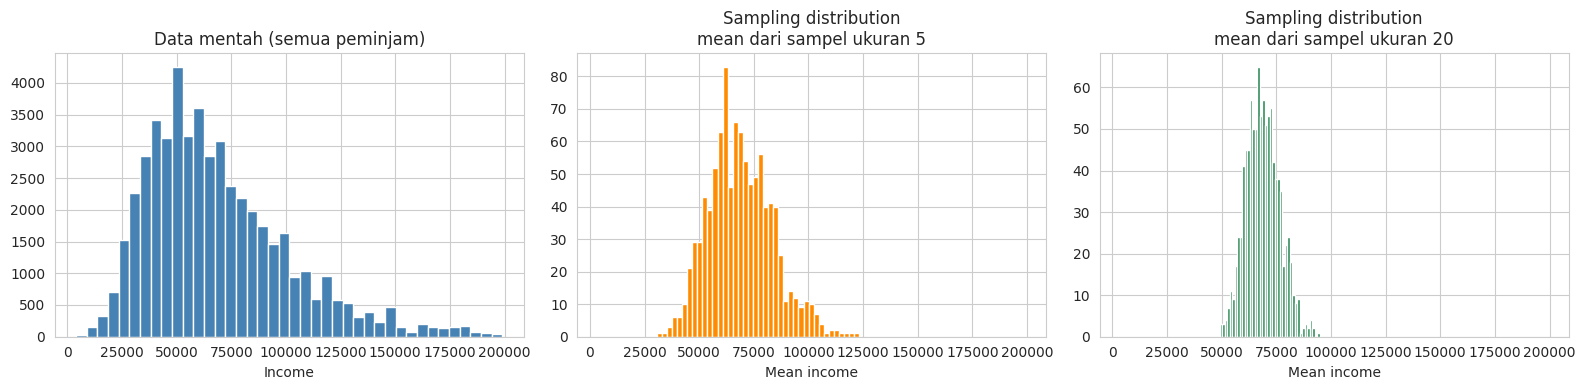

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

axes[0].hist(loans_income, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Data mentah (semua peminjam)")
axes[0].set_xlabel("Income")

axes[1].hist(means_of_5, bins=40, color="darkorange", edgecolor="white")
axes[1].set_title("Sampling distribution\nmean dari sampel ukuran 5")
axes[1].set_xlabel("Mean income")

axes[2].hist(means_of_20, bins=40, color="seagreen", edgecolor="white")
axes[2].set_title("Sampling distribution\nmean dari sampel ukuran 20")
axes[2].set_xlabel("Mean income")

plt.tight_layout()
plt.show()

Data mentahnya sendiri miring ke kanan (right-skewed), khas data pendapatan. Tapi begitu kita melihat mean dari banyak sampel, bentuknya jadi jauh lebih simetris dan menyerupai kurva normal, dan sebarannya makin sempit saat ukuran sampel naik dari 5 ke 20. Inilah inti dari sampling distribution dan Central Limit Theorem.

In [5]:
print(f"Standard error (sampel ukuran 5)  : {means_of_5.std():,.0f}")
print(f"Standard error (sampel ukuran 20) : {means_of_20.std():,.0f}")
print(f"Rasio (harus mendekati sqrt(20/5) = 2): {means_of_5.std() / means_of_20.std():.2f}")

Standard error (sampel ukuran 5)  : 14,622
Standard error (sampel ukuran 20) : 7,699
Rasio (harus mendekati sqrt(20/5) = 2): 1.90


## 4. The Bootstrap

**Bootstrap** adalah cara praktis untuk memperkirakan sampling distribution sebuah statistik tanpa perlu mengambil banyak sampel baru dari populasi (yang sering kali tidak mungkin di dunia nyata). Caranya: dari satu sampel yang kita punya, ambil ulang data itu **dengan pengembalian (with replacement)** sebanyak ukuran sampel aslinya, hitung statistiknya, lalu ulangi ribuan kali.

Hasilnya, kumpulan statistik dari tiap resample ini mendekati bentuk sampling distribution yang sebenarnya, tanpa perlu asumsi teoretis yang rumit soal bentuk distribusinya.

In [6]:
def bootstrap_statistic(data, statistic_fn, n_iterations=2000):
    n = len(data)
    results = np.empty(n_iterations)
    for i in range(n_iterations):
        resample = data.sample(n=n, replace=True)
        results[i] = statistic_fn(resample)
    return pd.Series(results)

# Bootstrap distribution untuk median income, dari satu sampel berukuran 1000
sampel = loans_income.sample(1000, random_state=42)
boot_median = bootstrap_statistic(sampel, np.median, n_iterations=2000)

print(f"Median dari sampel asli        : {sampel.median():,.0f}")
print(f"Mean dari bootstrap distribution: {boot_median.mean():,.0f}")
print(f"Standard error (bootstrap)      : {boot_median.std():,.0f}")

Median dari sampel asli        : 60,000
Mean dari bootstrap distribution: 60,216
Standard error (bootstrap)      : 719


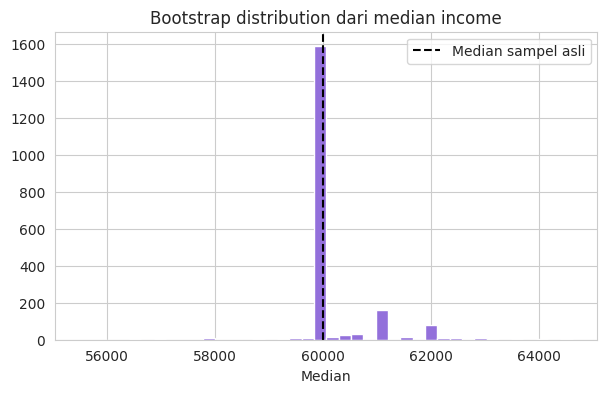

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boot_median, bins=40, color="mediumpurple", edgecolor="white")
ax.axvline(sampel.median(), color="black", linestyle="--", label="Median sampel asli")
ax.set_title("Bootstrap distribution dari median income")
ax.set_xlabel("Median")
ax.legend()
plt.show()

## 5. Confidence Intervals

**Confidence interval** memberi gambaran seberapa tidak pasti sebuah estimasi statistik, dinyatakan sebagai rentang nilai, bukan satu angka tunggal. Cara paling praktis menghitungnya adalah lewat bootstrap: ambil persentil tertentu dari bootstrap distribution.

Misalnya untuk **90% confidence interval**, kita ambil persentil ke-5 dan ke-95 dari hasil bootstrap. Interpretasinya bukan "90% peluang nilai sebenarnya ada di rentang ini", tapi lebih ke: kalau prosedur ini diulang berkali-kali pada sampel yang berbeda-beda, sekitar 90% dari interval yang dihasilkan akan memuat nilai populasi yang sebenarnya.

In [8]:
ci_lower, ci_upper = boot_median.quantile([0.05, 0.95])

print(f"90% confidence interval untuk median income: ({ci_lower:,.0f}, {ci_upper:,.0f})")

90% confidence interval untuk median income: (60,000, 62,000)


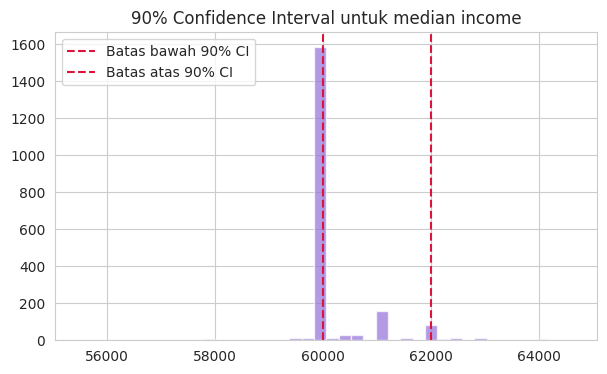

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boot_median, bins=40, color="mediumpurple", edgecolor="white", alpha=0.7)
ax.axvline(ci_lower, color="crimson", linestyle="--", label="Batas bawah 90% CI")
ax.axvline(ci_upper, color="crimson", linestyle="--", label="Batas atas 90% CI")
ax.set_title("90% Confidence Interval untuk median income")
ax.legend()
plt.show()

## 6. Normal Distribution

**Distribusi normal** (kurva lonceng) adalah salah satu distribusi paling penting dalam statistik, terutama karena sampling distribution dari mean cenderung mendekati bentuk ini (Central Limit Theorem), walau data mentahnya sendiri tidak normal.

Cara paling umum mengecek apakah suatu data mendekati distribusi normal adalah dengan **QQ-plot (Quantile-Quantile plot)**: kalau titik-titiknya mengikuti garis lurus diagonal, datanya mendekati normal. Kalau titik-titik di ujung melenceng jauh dari garis, itu tanda ada ekor yang lebih berat (fat tails) dibanding distribusi normal.

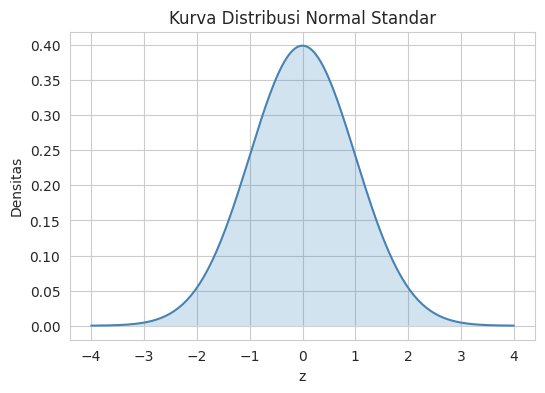

In [10]:
x = np.linspace(-4, 4, 200)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, color="steelblue")
ax.fill_between(x, y, alpha=0.2)
ax.set_title("Kurva Distribusi Normal Standar")
ax.set_xlabel("z")
ax.set_ylabel("Densitas")
plt.show()

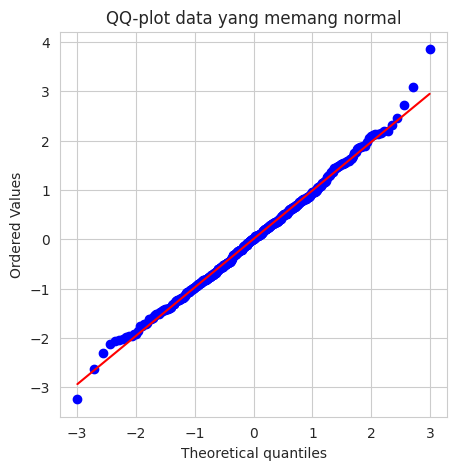

In [11]:
data_normal = stats.norm.rvs(loc=0, scale=1, size=500, random_state=42)

fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(data_normal, dist="norm", plot=ax)
ax.set_title("QQ-plot data yang memang normal")
plt.show()

## 7. Long-Tailed Distributions

Meski distribusi normal penting secara teori, banyak data di dunia nyata, terutama di bidang keuangan, tidak mengikuti pola ini. Data seperti itu punya **ekor yang lebih berat (long-tailed / fat-tailed)**, artinya kejadian ekstrem jauh lebih sering muncul dibanding yang diprediksi distribusi normal.

Buku memakai contoh return harian saham Netflix (NFLX) untuk menunjukkan ini secara real lewat QQ-plot.

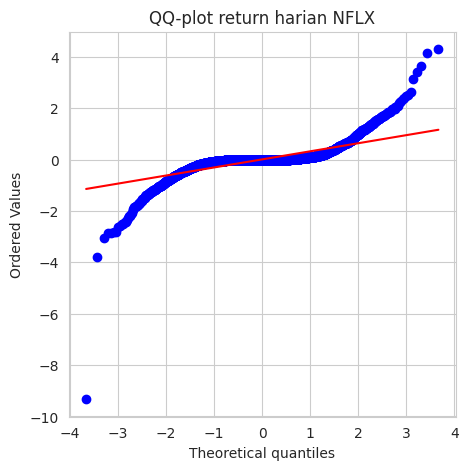

In [12]:
sp500_data = pd.read_csv(BASE + "sp500_data.csv.gz", index_col=0)
nflx_returns = sp500_data["NFLX"].dropna()

# Ubah ke log return, sesuai pendekatan buku
nflx_log_returns = np.diff(np.log(nflx_returns.cumsum() - nflx_returns.cumsum().min() + 1))

fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(nflx_returns, dist="norm", plot=ax)
ax.set_title("QQ-plot return harian NFLX")
plt.show()

Kalau return NFLX benar-benar mengikuti distribusi normal, titik-titiknya akan mengikuti garis lurus. Kenyataannya, titik-titik di kedua ujung melenceng jauh ke atas/bawah garis, tanda bahwa hari-hari dengan return sangat ekstrem (baik untung besar maupun rugi besar) jauh lebih sering terjadi dibanding yang diperkirakan model normal. Ini alasan kenapa model risiko keuangan sering memakai distribusi lain yang punya ekor lebih berat, seperti Student's t.

## 8. Student's t-Distribution

**Distribusi-t** bentuknya mirip distribusi normal, tapi punya ekor yang lebih berat, sehingga lebih cocok untuk merepresentasikan ketidakpastian ketika ukuran sampel kecil atau standar deviasi populasi tidak diketahui. Distribusi ini dikendalikan oleh satu parameter: **degrees of freedom (df)**. Makin kecil df, makin berat ekornya; makin besar df, makin mirip distribusi normal.

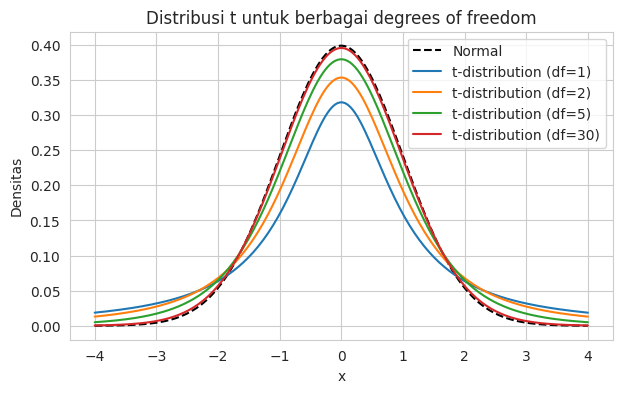

In [13]:
x = np.linspace(-4, 4, 200)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, stats.norm.pdf(x), label="Normal", color="black", linestyle="--")
for df in [1, 2, 5, 30]:
    ax.plot(x, stats.t.pdf(x, df=df), label=f"t-distribution (df={df})")

ax.set_title("Distribusi t untuk berbagai degrees of freedom")
ax.set_xlabel("x")
ax.set_ylabel("Densitas")
ax.legend()
plt.show()

Terlihat bahwa saat df kecil (df=1 atau 2), ekor distribusi-t jauh lebih tebal dibanding normal. Semakin besar df (misalnya df=30), kurvanya makin sulit dibedakan dari distribusi normal.

## 9. Binomial Distribution

**Distribusi binomial** memodelkan jumlah "sukses" dari sejumlah percobaan independen, di mana tiap percobaan hanya punya dua kemungkinan hasil (sukses/gagal) dengan peluang sukses yang tetap. Contoh klasik: jumlah kepala dari n kali lempar koin, atau jumlah pelanggan yang membeli dari n pengunjung website.

Dua parameter utamanya: **n** (jumlah percobaan) dan **p** (peluang sukses tiap percobaan).

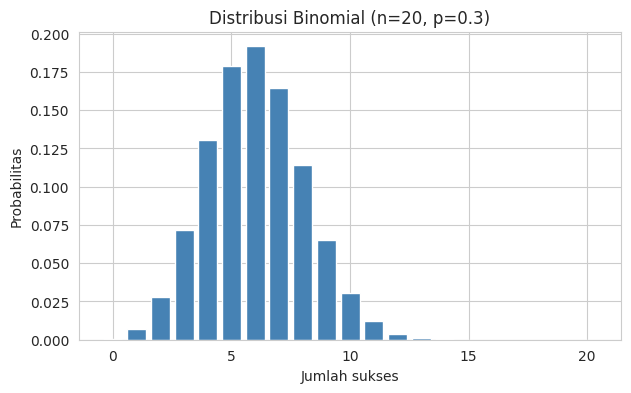

Mean   : 6.00
Std dev: 2.05


In [14]:
n, p = 20, 0.3
x = np.arange(0, n + 1)
pmf = stats.binom.pmf(x, n, p)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x, pmf, color="steelblue")
ax.set_title(f"Distribusi Binomial (n={n}, p={p})")
ax.set_xlabel("Jumlah sukses")
ax.set_ylabel("Probabilitas")
plt.show()

print(f"Mean   : {stats.binom.mean(n, p):.2f}")
print(f"Std dev: {stats.binom.std(n, p):.2f}")

## 10. Chi-Square Distribution

**Distribusi chi-square** muncul terutama dalam konteks pengujian apakah dua variabel kategorikal saling independen (uji chi-square), dengan membandingkan hasil yang diamati terhadap yang diharapkan kalau tidak ada hubungan. Bentuknya dikendalikan oleh **degrees of freedom**, dan selalu bernilai non-negatif.

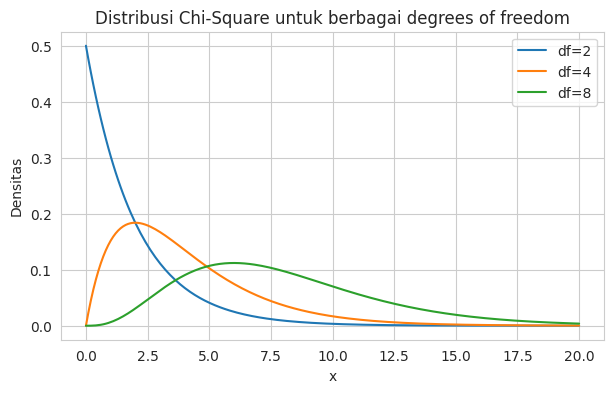

In [15]:
x = np.linspace(0, 20, 200)

fig, ax = plt.subplots(figsize=(7, 4))
for df in [2, 4, 8]:
    ax.plot(x, stats.chi2.pdf(x, df=df), label=f"df={df}")

ax.set_title("Distribusi Chi-Square untuk berbagai degrees of freedom")
ax.set_xlabel("x")
ax.set_ylabel("Densitas")
ax.legend()
plt.show()

## 11. F-Distribution

**Distribusi F** dipakai terutama saat membandingkan variabilitas antar lebih dari dua kelompok sekaligus (analysis of variance / ANOVA), yaitu menguji apakah perbedaan antar kelompok lebih besar daripada yang bisa dijelaskan oleh variasi acak biasa. Distribusi ini dikendalikan oleh dua parameter degrees of freedom, satu untuk pembilang, satu untuk penyebut.

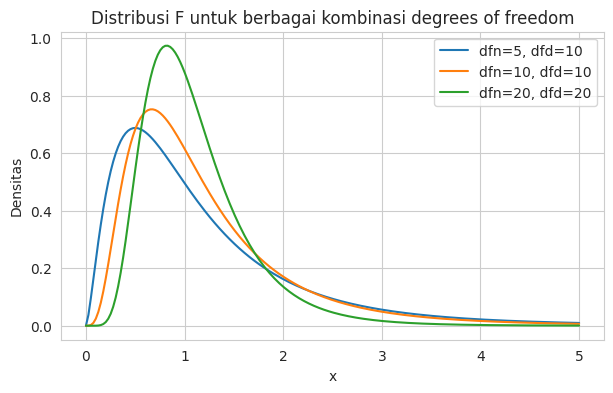

In [16]:
x = np.linspace(0, 5, 200)

fig, ax = plt.subplots(figsize=(7, 4))
for dfn, dfd in [(5, 10), (10, 10), (20, 20)]:
    ax.plot(x, stats.f.pdf(x, dfn, dfd), label=f"dfn={dfn}, dfd={dfd}")

ax.set_title("Distribusi F untuk berbagai kombinasi degrees of freedom")
ax.set_xlabel("x")
ax.set_ylabel("Densitas")
ax.legend()
plt.show()

## 12. Poisson dan Distribusi Terkait

Sekelompok distribusi ini berguna untuk memodelkan kejadian yang muncul secara acak dalam rentang waktu atau ruang tertentu, dengan satu parameter kunci: **lambda (λ)**, yaitu rata-rata jumlah kejadian per unit waktu/ruang.

- **Poisson**: memodelkan berapa kali suatu kejadian muncul dalam periode tertentu, misalnya jumlah panggilan masuk ke call center per jam.
- **Exponential**: memodelkan waktu *antar* kejadian, misalnya jarak waktu antar kedatangan pelanggan. Memakai parameter lambda yang sama dengan Poisson.
- **Weibull**: perluasan dari exponential untuk kasus di mana laju kejadian tidak konstan sepanjang waktu, misalnya laju kerusakan komponen yang makin tinggi seiring usia pemakaian (dikendalikan tambahan parameter *shape*).

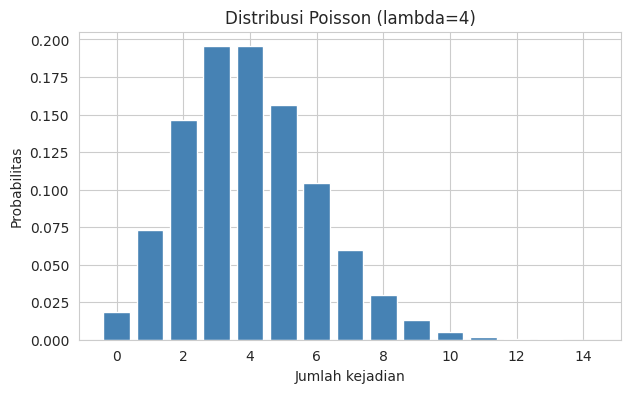

In [17]:
lam = 4  # rata-rata 4 kejadian per periode
x = np.arange(0, 15)
pmf_poisson = stats.poisson.pmf(x, mu=lam)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x, pmf_poisson, color="steelblue")
ax.set_title(f"Distribusi Poisson (lambda={lam})")
ax.set_xlabel("Jumlah kejadian")
ax.set_ylabel("Probabilitas")
plt.show()

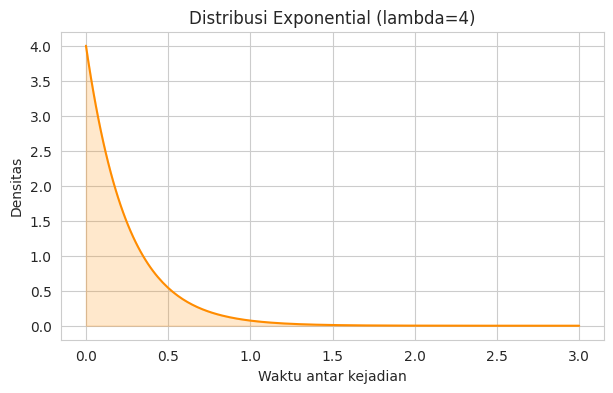

In [18]:
x = np.linspace(0, 3, 200)
pdf_exp = stats.expon.pdf(x, scale=1 / lam)  # scale = 1/lambda

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, pdf_exp, color="darkorange")
ax.fill_between(x, pdf_exp, alpha=0.2, color="darkorange")
ax.set_title(f"Distribusi Exponential (lambda={lam})")
ax.set_xlabel("Waktu antar kejadian")
ax.set_ylabel("Densitas")
plt.show()

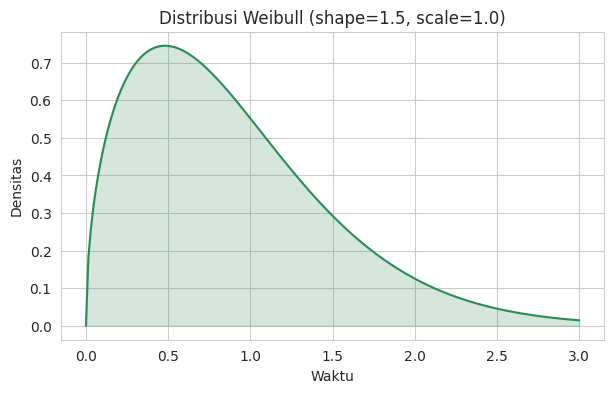

In [19]:
x = np.linspace(0, 3, 200)
shape, scale = 1.5, 1.0  # shape > 1 berarti laju kejadian meningkat seiring waktu

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, stats.weibull_min.pdf(x, shape, scale=scale), color="seagreen")
ax.fill_between(x, stats.weibull_min.pdf(x, shape, scale=scale), alpha=0.2, color="seagreen")
ax.set_title(f"Distribusi Weibull (shape={shape}, scale={scale})")
ax.set_xlabel("Waktu")
ax.set_ylabel("Densitas")
plt.show()

## Poin-poin Penting Bab 2

- Random sampling yang baik lebih penting daripada sekadar ukuran data yang besar, karena bias dalam cara memilih data tidak hilang hanya dengan menambah jumlahnya.
- Sampling distribution (distribusi sebuah statistik dari banyak sampel) berbeda dengan data distribution (distribusi data mentah), dan cenderung lebih mendekati normal serta lebih sempit seiring ukuran sampel membesar.
- Bootstrap adalah cara praktis mengestimasi sampling distribution dan confidence interval hanya dari satu sampel, dengan resampling with replacement.
- Distribusi normal penting secara teori, tapi banyak data nyata (terutama data finansial) punya ekor lebih berat, yang bisa dicek lewat QQ-plot.
- Distribusi-t, chi-square, F, binomial, Poisson, exponential, dan Weibull masing-masing punya konteks penggunaan spesifik, dan akan sering muncul lagi di bab-bab pengujian hipotesis berikutnya.

Referensi: Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists*, 2nd Edition, Bab 2 "Data and Sampling Distributions". O'Reilly Media. Dataset: repo data resmi buku di GitHub (gedeck/practical-statistics-for-data-scientists).